# Analysis — Generate All Figures (ImageNet-100)
**Run after all 12 training runs are complete.**
Takes ~3h for analysis + seconds for plotting.


In [1]:
!nvidia-smi
import torch
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Thu Jun 11 12:25:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             44W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [10]:
# Copy and verify script
import os
SCRIPT_DIR = '/content/drive/My Drive/pe_experiment'
import shutil
shutil.copy2(os.path.join(SCRIPT_DIR, 'full_scale_experiment.py'), '/content/')
!grep '_orig_mod\|max_components\|min_epochs\|ImageNet-100' /content/full_scale_experiment.py | head -6
print('✅ Latest script confirmed')


Dataset:    ImageNet-100 (100 classes, 224x224, ~130K train / ~5K val)
    """ImageNet-100 data loaders using standard ImageFolder.
        max_components = min(embed_dim, pe_matrix.shape[0], pe_matrix.shape[1])
        pca = PCA(n_components=max_components)
        if max_components < embed_dim:
            pad = np.zeros((pe_matrix.shape[0], embed_dim - max_components))
✅ Latest script confirmed


In [4]:
!pip install -q timm tqdm scikit-learn scipy matplotlib


learned: shape=(197, 768)
sinusoidal: shape=(197, 768)
rope: shape=(197, 768)
alibi: shape=(197, 768)


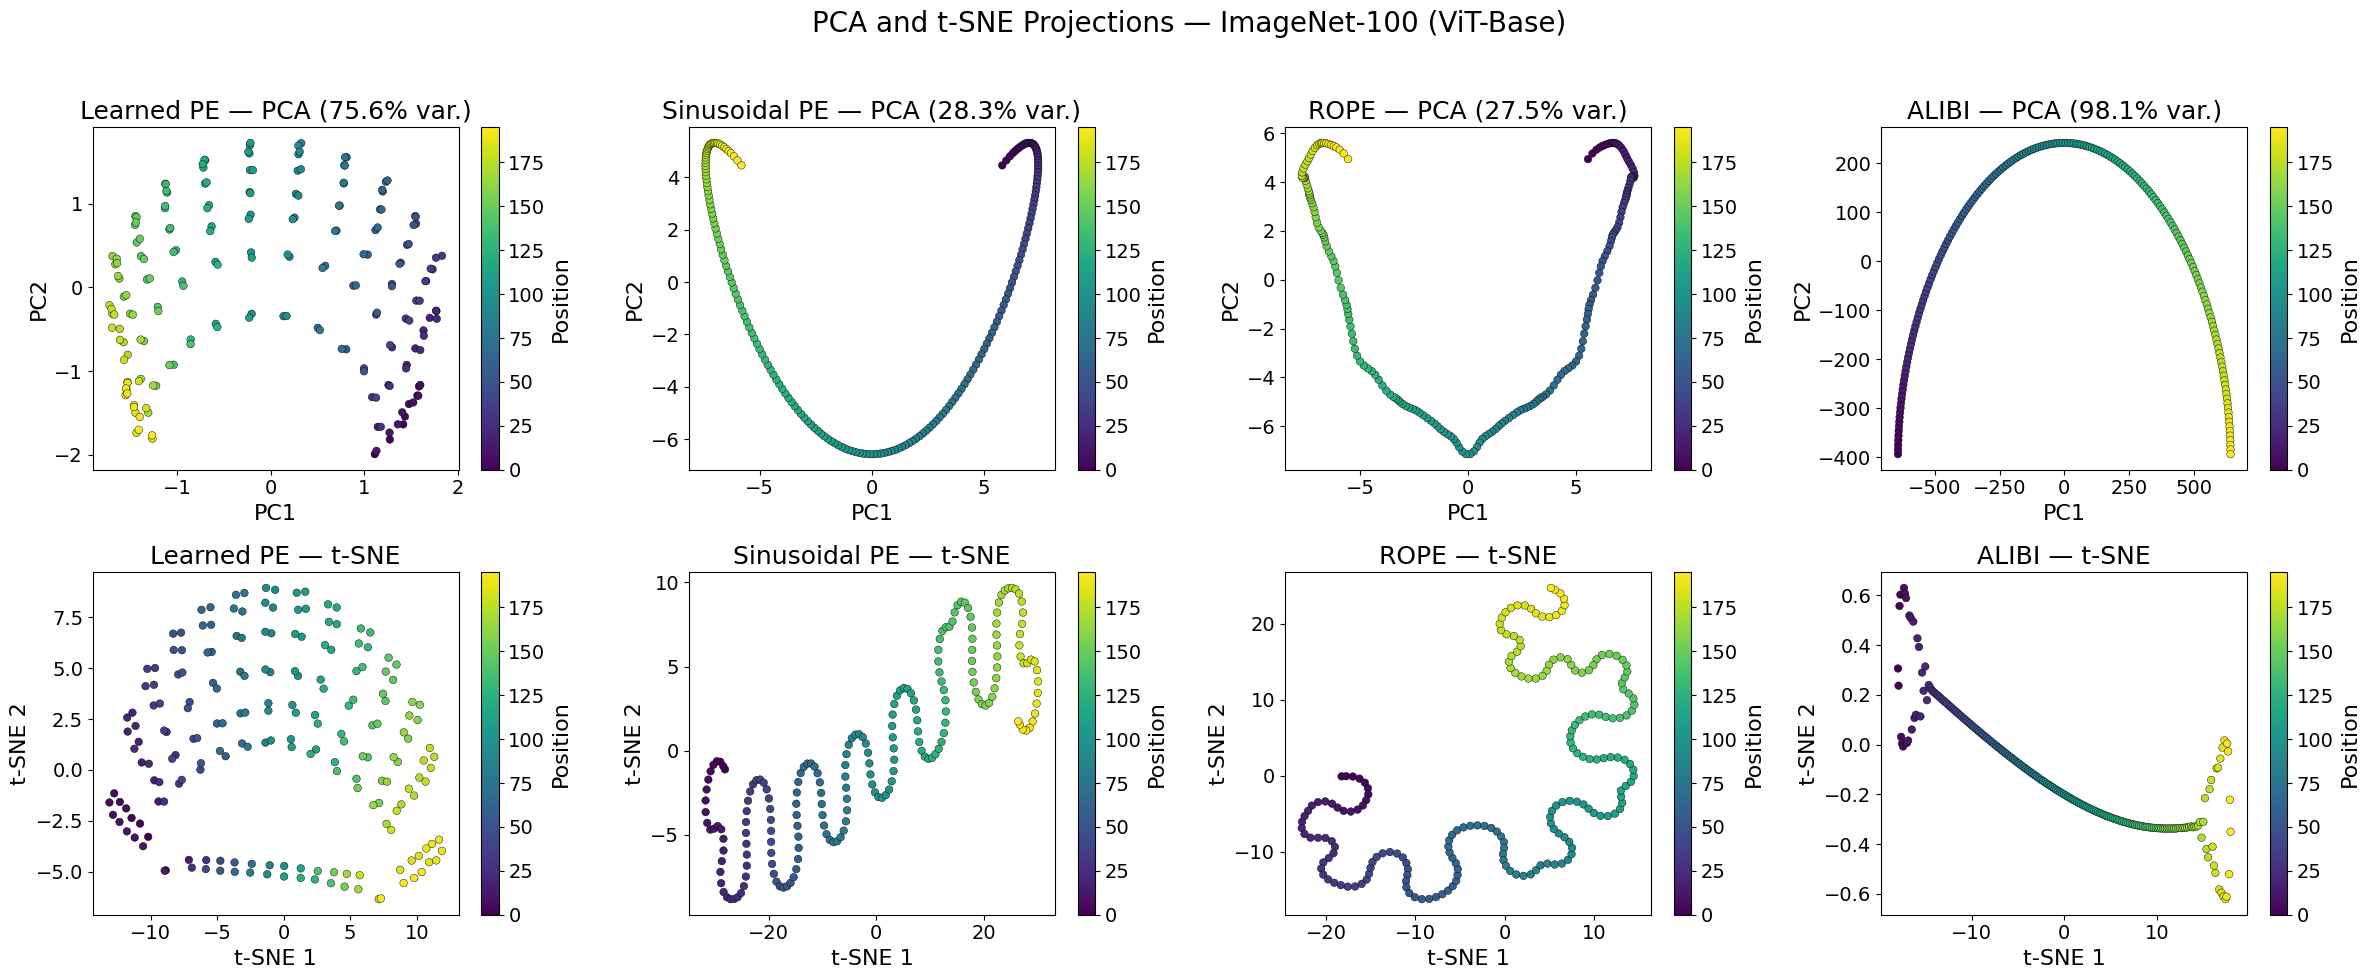

✅ Saved!


In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import sys

plt.rcParams.update({
    'font.size': 14,          # Veličina brojeva na osama (ticks) i colorbar-u
    'axes.labelsize': 16,     # Veličina za 'PC1', 'PC2', 't-SNE 1', 't-SNE 2'
    'axes.titlesize': 18,     # Veličina za naslove podgrafika (npr. 'LEARNED PE — PCA...')
    'figure.titlesize': 24,   # Veličina za glavni naslov (suptitle)
    'legend.fontsize': 14     # Veličina za legende (ako ih budeš dodavao)
})

sys.path.insert(0, '/content')
from full_scale_experiment import VisionTransformer, extract_positional_embedding

device = 'cuda' if torch.cuda.is_available() else 'cpu'
RESULTS = '/content/drive/My Drive/pe_experiment/results'

# Load one model per PE type and extract PE matrix
pe_matrices = {}
for pe_type in ['learned', 'sinusoidal', 'rope', 'alibi']:
    path = f'{RESULTS}/{pe_type}_seed42/best_model.pth'
    model = VisionTransformer(
        img_size=224, patch_size=16, num_classes=100, embed_dim=768,
        depth=12, num_heads=12, mlp_ratio=4.0, dropout=0.1, pe_type=pe_type
    ).to(device)
    state = torch.load(path, map_location=device)
    model.load_state_dict({k.replace('_orig_mod.', ''): v for k, v in state.items()})
    pe_matrices[pe_type] = extract_positional_embedding(model, pe_type)
    print(f'{pe_type}: shape={pe_matrices[pe_type].shape}')

# Plot
n = len(pe_matrices)
fig, axes = plt.subplots(2, n, figsize=(6*n, 10))
positions = np.arange(196)

for col, (pe_type, pe_matrix) in enumerate(pe_matrices.items()):
    patches = pe_matrix[1:]  # exclude CLS
    # PCA
    pca = PCA(n_components=2)
    proj_pca = pca.fit_transform(patches)
    var = pca.explained_variance_ratio_.sum()
    label = pe_type.upper() if pe_type in ('rope','alibi') else f"{pe_type.capitalize()} PE"

    sc1 = axes[0,col].scatter(proj_pca[:,0], proj_pca[:,1], c=positions, cmap='viridis', s=30, edgecolors='k', linewidth=0.3)
    axes[0,col].set_title(f'{label} — PCA ({var*100:.1f}% var.)')
    axes[0,col].set_xlabel('PC1'); axes[0,col].set_ylabel('PC2')
    plt.colorbar(sc1, ax=axes[0,col], label='Position')

    # t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    proj_tsne = tsne.fit_transform(patches)
    sc2 = axes[1,col].scatter(proj_tsne[:,0], proj_tsne[:,1], c=positions, cmap='viridis', s=30, edgecolors='k', linewidth=0.3)
    axes[1,col].set_title(f'{label} — t-SNE')
    axes[1,col].set_xlabel('t-SNE 1'); axes[1,col].set_ylabel('t-SNE 2')
    plt.colorbar(sc2, ax=axes[1,col], label='Position')

fig.suptitle('PCA and t-SNE Projections — ImageNet-100 (ViT-Base)', fontsize=20, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('/content/drive/My Drive/pe_experiment/results/figures/03_pca_tsne.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved!')

In [7]:
# ============================================
# EXTRACT IMAGENET-100 + RESIZE TO 256px
# ============================================

import os, time, tarfile, shutil, subprocess
from PIL import Image

DRIVE_BASE = '/content/drive/My Drive/pe_experiment'
RESULTS_DIR = os.path.join(DRIVE_BASE, 'results')
SCRIPT_DIR = DRIVE_BASE
DATA_DIR = '/content/imagenet100_resized'
IN100_RAW = '/content/imagenet100_raw'

train_path = os.path.join(DATA_DIR, 'train')
val_path = os.path.join(DATA_DIR, 'val')

if (os.path.exists(train_path) and len(os.listdir(train_path)) >= 100
    and os.path.exists(val_path) and len(os.listdir(val_path)) >= 100):
    print(f'✅ ImageNet-100 already on SSD')
else:
    imagenet_dir = os.path.join(DRIVE_BASE, 'imagenet')
    TRAIN_TAR = None
    VAL_TAR = None
    for name in ['ILSVRC2012_img_train.tar', 'ILSVRC2012_img_train']:
        c = os.path.join(imagenet_dir, name)
        if os.path.exists(c): TRAIN_TAR = c; break
    for name in ['ILSVRC2012_img_val.tar', 'ILSVRC2012_img_val']:
        c = os.path.join(imagenet_dir, name)
        if os.path.exists(c): VAL_TAR = c; break
    print(f'Train tar: {TRAIN_TAR}')
    print(f'Val tar: {VAL_TAR}')

    subprocess.run(['wget', '-q',
        'https://raw.githubusercontent.com/HobbitLong/CMC/master/imagenet100.txt',
        '-O', '/content/imagenet100.txt'], check=True)
    with open('/content/imagenet100.txt') as f:
        class_set = set(line.strip() for line in f if line.strip())
    print(f'Target classes: {len(class_set)}')

    t0 = time.time()

    print('Step 1/3: Extracting train...')
    raw_train = os.path.join(IN100_RAW, 'train')
    os.makedirs(raw_train, exist_ok=True)
    tf = tarfile.open(TRAIN_TAR, 'r|')
    found = 0
    for member in tf:
        if not member.name.endswith('.tar'): continue
        class_name = os.path.basename(member.name).replace('.tar', '')
        if class_name in class_set:
            class_dir = os.path.join(raw_train, class_name)
            os.makedirs(class_dir, exist_ok=True)
            fileobj = tf.extractfile(member)
            with tarfile.open(fileobj=fileobj, mode='r|') as ctf:
                ctf.extractall(class_dir)
            found += 1
            if found % 10 == 0: print(f'  {found}/100 classes ({time.time()-t0:.0f}s)')
            if found >= len(class_set): break
        else:
            tf.extractfile(member).read()
    tf.close()
    print(f'  Train: {found} classes')

    print('Step 2/3: Extracting val...')
    val_tmp = '/content/val_tmp'
    os.makedirs(val_tmp, exist_ok=True)
    with tarfile.open(VAL_TAR, 'r|') as vtf:
        vtf.extractall(val_tmp)
    subprocess.run(['wget', '-q',
        'https://raw.githubusercontent.com/tensorflow/models/master/research/slim/datasets/imagenet_2012_validation_synset_labels.txt',
        '-O', '/content/val_synsets.txt'], check=True)
    with open('/content/val_synsets.txt') as f:
        val_synsets = [line.strip() for line in f]
    raw_val = os.path.join(IN100_RAW, 'val')
    os.makedirs(raw_val, exist_ok=True)
    val_images = sorted([f for f in os.listdir(val_tmp) if f.endswith('.JPEG')])
    for img_name, synset in zip(val_images, val_synsets):
        if synset in class_set:
            class_dir = os.path.join(raw_val, synset)
            os.makedirs(class_dir, exist_ok=True)
            shutil.move(os.path.join(val_tmp, img_name), os.path.join(class_dir, img_name))
    shutil.rmtree(val_tmp)

    print('Step 3/3: Resizing to 256px...')
    for split in ['train', 'val']:
        src_split = os.path.join(IN100_RAW, split)
        dst_split = os.path.join(DATA_DIR, split)
        for cls in os.listdir(src_split):
            cls_src = os.path.join(src_split, cls)
            cls_dst = os.path.join(dst_split, cls)
            os.makedirs(cls_dst, exist_ok=True)
            for img_name in os.listdir(cls_src):
                dst_p = os.path.join(cls_dst, img_name)
                if not os.path.exists(dst_p):
                    img = Image.open(os.path.join(cls_src, img_name)).convert('RGB')
                    img.thumbnail((256, 256), Image.LANCZOS)
                    img.save(dst_p, 'JPEG', quality=95)
        print(f'  {split} done')
    shutil.rmtree(IN100_RAW)
    print(f'✅ Done in {(time.time()-t0)/60:.1f} min')


Train tar: /content/drive/My Drive/pe_experiment/imagenet/ILSVRC2012_img_train.tar
Val tar: /content/drive/My Drive/pe_experiment/imagenet/ILSVRC2012_img_val.tar
Target classes: 100
Step 1/3: Extracting train...


/tmp/ipykernel_1682/2781955925.py:55: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  ctf.extractall(class_dir)


  10/100 classes (353s)
  20/100 classes (473s)
  30/100 classes (636s)
  40/100 classes (813s)
  50/100 classes (1156s)
  60/100 classes (1493s)
  70/100 classes (1661s)
  80/100 classes (1884s)
  90/100 classes (2128s)
  100/100 classes (2436s)
  Train: 100 classes
Step 2/3: Extracting val...


/tmp/ipykernel_1682/2781955925.py:68: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  vtf.extractall(val_tmp)


Step 3/3: Resizing to 256px...
  train done
  val done
✅ Done in 58.3 min


In [11]:
# Verify all 12 models
import os, json
for pe in ['learned', 'sinusoidal', 'rope', 'alibi']:
    for s in [42, 123, 456]:
        path = os.path.join(RESULTS_DIR, f'{pe}_seed{s}')
        has_best = os.path.exists(os.path.join(path, 'best_model.pth'))
        has_hist = os.path.exists(os.path.join(path, 'training_history.json'))
        acc = ''
        if has_hist:
            with open(os.path.join(path, 'training_history.json')) as f:
                h = json.load(f)
            acc = f'best={max(h["val_acc"]):.2f}%'
        status = '✅' if has_best and has_hist else '❌'
        print(f'{status} {pe:12s} seed={s:3d}  {acc}')


✅ learned      seed= 42  best=79.68%
✅ learned      seed=123  best=79.90%
✅ learned      seed=456  best=78.74%
✅ sinusoidal   seed= 42  best=81.84%
✅ sinusoidal   seed=123  best=81.30%
✅ sinusoidal   seed=456  best=81.24%
✅ rope         seed= 42  best=84.96%
✅ rope         seed=123  best=84.18%
✅ rope         seed=456  best=84.38%
✅ alibi        seed= 42  best=81.16%
✅ alibi        seed=123  best=81.34%
✅ alibi        seed=456  best=80.66%


## 🚀 Run Analysis (~3h)


In [14]:
# Resolves the problem with torch.compile in the script

with open("/content/full_scale_experiment.py", "r") as f:
    kod = f.read()

# We are looking for line 1544
stara_linija = "model.load_state_dict(torch.load(model_path, map_location=device))"

# We define a fix that cleans the '_orig_mod.' prefixes
nova_linija = """state_dict = torch.load(model_path, map_location=device)
                fixed_state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
                model.load_state_dict(fixed_state_dict)"""

if stara_linija in kod:
    kod = kod.replace(stara_linija, nova_linija)
    with open("/content/full_scale_experiment.py", "w") as f:
        f.write(kod)
    print("✅ The script has been successfully fixed! Now you can run the analysis.")
else:
    print("⚠️ Line not found. Check if the file is at the path /content/full_scale_experiment.py")

✅ Skripta je uspešno popravljena! Sada možeš pokrenuti analizu.


In [16]:
# Run this cell to automatically import the missing StratifiedKFold

with open("/content/full_scale_experiment.py", "r") as f:
    kod = f.read()

# We define the missing import
potreban_import = "from sklearn.model_selection import StratifiedKFold"

# We add it to the very beginning of the code, right beneath the first library import
if potreban_import not in kod:
    kod = kod.replace("import os", f"import os\n{potreban_import}")
    with open("/content/full_scale_experiment.py", "w") as f:
        f.write(kod)
    print("✅ The script has been successfully fixed! 'StratifiedKFold' has been imported.")
else:
    print("⚠️ The import is already present or the file structure has been changed.")

✅ Skripta je uspešno popravljena! 'StratifiedKFold' je uvezen.


In [17]:
# Run full analysis + figure generation
!python /content/full_scale_experiment.py \
    --data_dir /content/imagenet100_resized \
    --output_dir "/content/drive/My Drive/pe_experiment/results" \
    --mode analyze \
    --num_classes 100


Device: cuda
PE types: ['learned', 'sinusoidal', 'rope', 'alibi']
Seeds: [42, 123, 456]
Config: {
  "img_size": 224,
  "patch_size": 16,
  "num_classes": 100,
  "embed_dim": 768,
  "depth": 12,
  "num_heads": 12,
  "mlp_ratio": 4.0,
  "dropout": 0.1,
  "lr": 0.0003,
  "weight_decay": 0.1,
  "warmup_epochs": 20,
  "epochs": 300,
  "batch_size": 256,
  "label_smoothing": 0.1,
  "use_mixup": true,
  "mixup_alpha": 0.8
}

Loading ImageNet-100...
  Train: 126689 images
  Val: 5000 images

ANALYSIS PHASE

--- Analyzing: learned PE, seed=42 ---
  Running probe analysis...
    Probe row: 74.5% +/- 6.8%
    Probe column: 38.3% +/- 7.7%
    Probe position: 87.8% (no CV, n_per_class=1)
  Computing MI per layer...
  Computing attention entropy...
  Running noise ablation...
    Noise 0.0x sigma_PE: accuracy = 79.68%
    Noise 0.1x sigma_PE: accuracy = 79.76%
    Noise 0.2x sigma_PE: accuracy = 79.62%
    Noise 0.5x sigma_PE: accuracy = 79.72%
    Noise 1.0x sigma_PE: accuracy = 79.46%
    Noise 2.

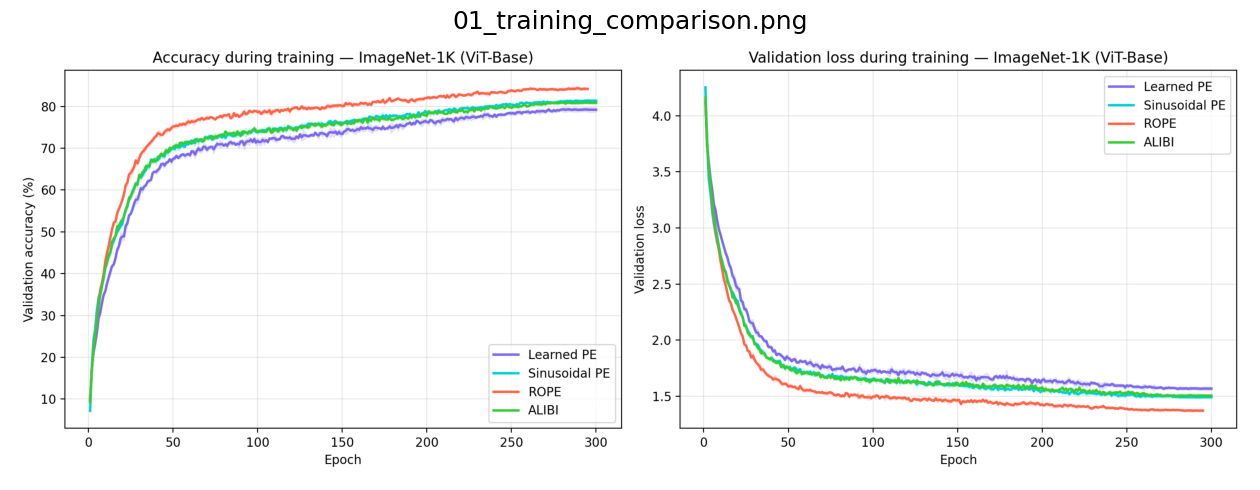

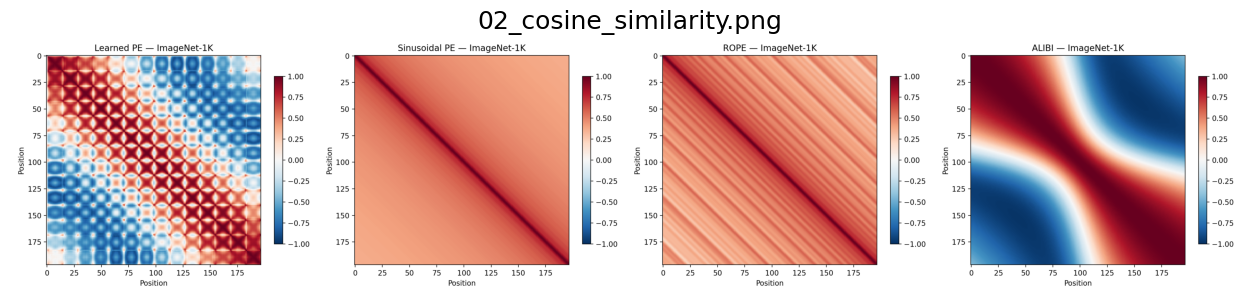

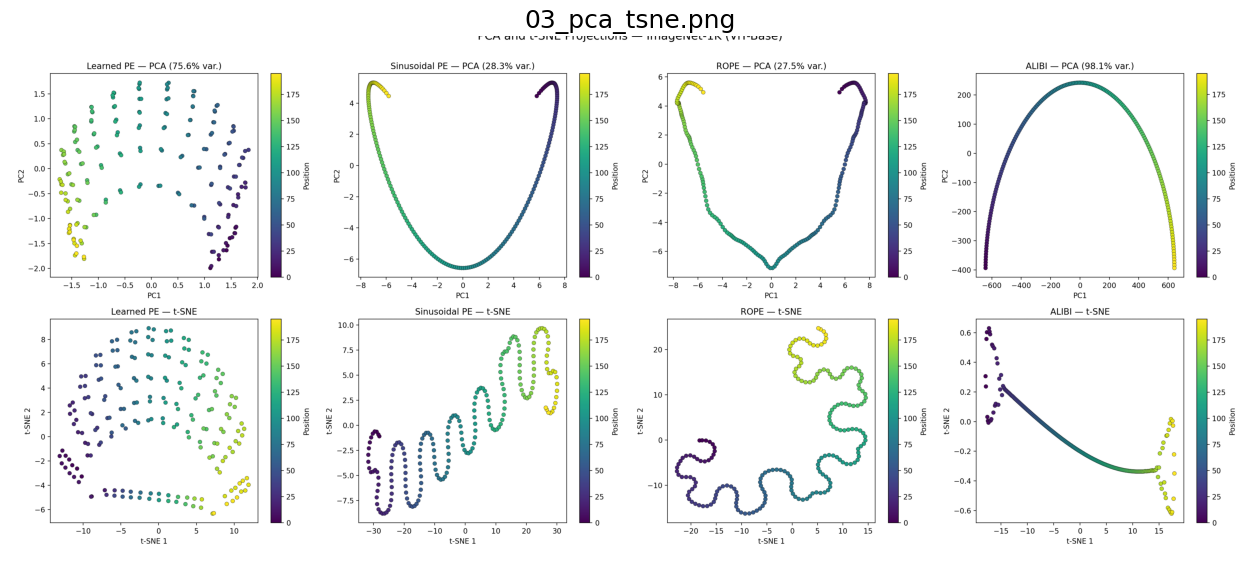

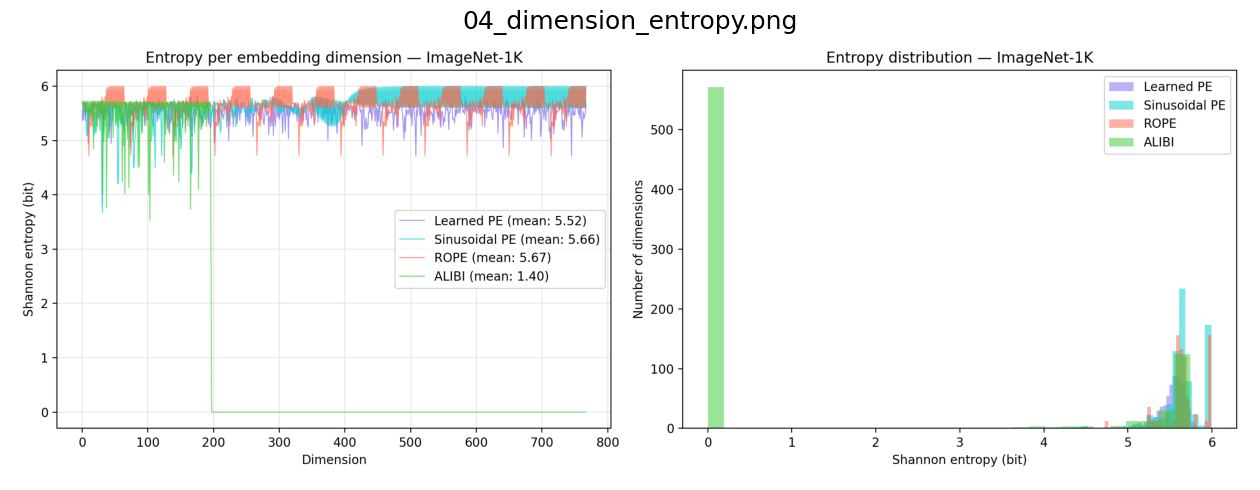

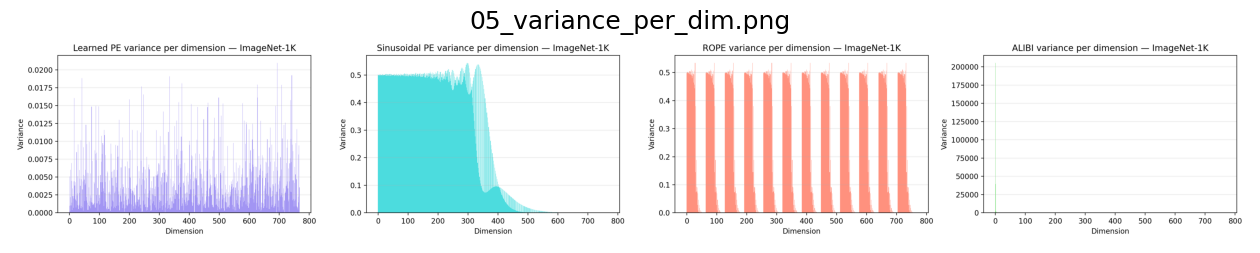

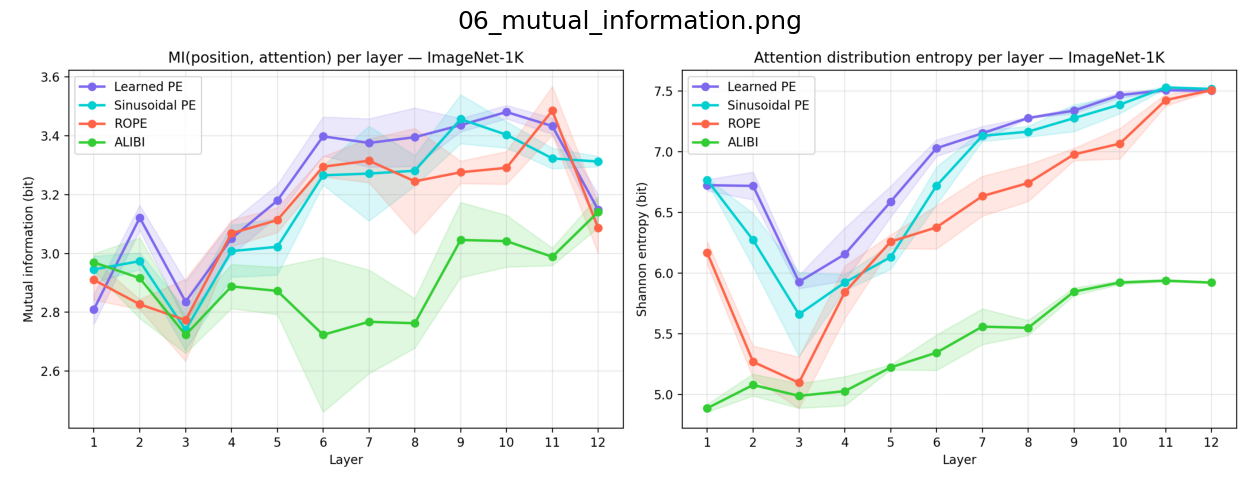

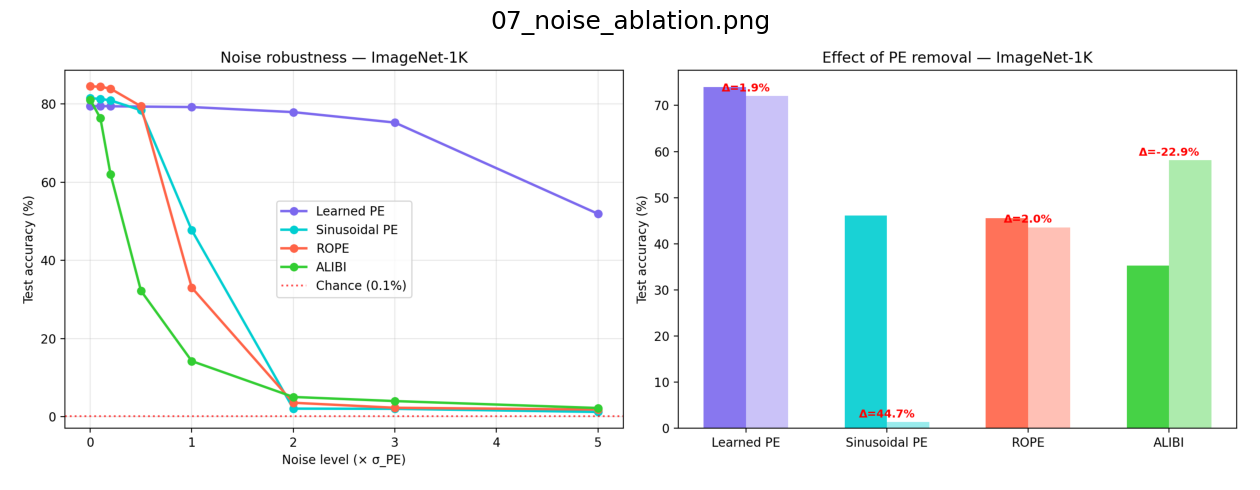

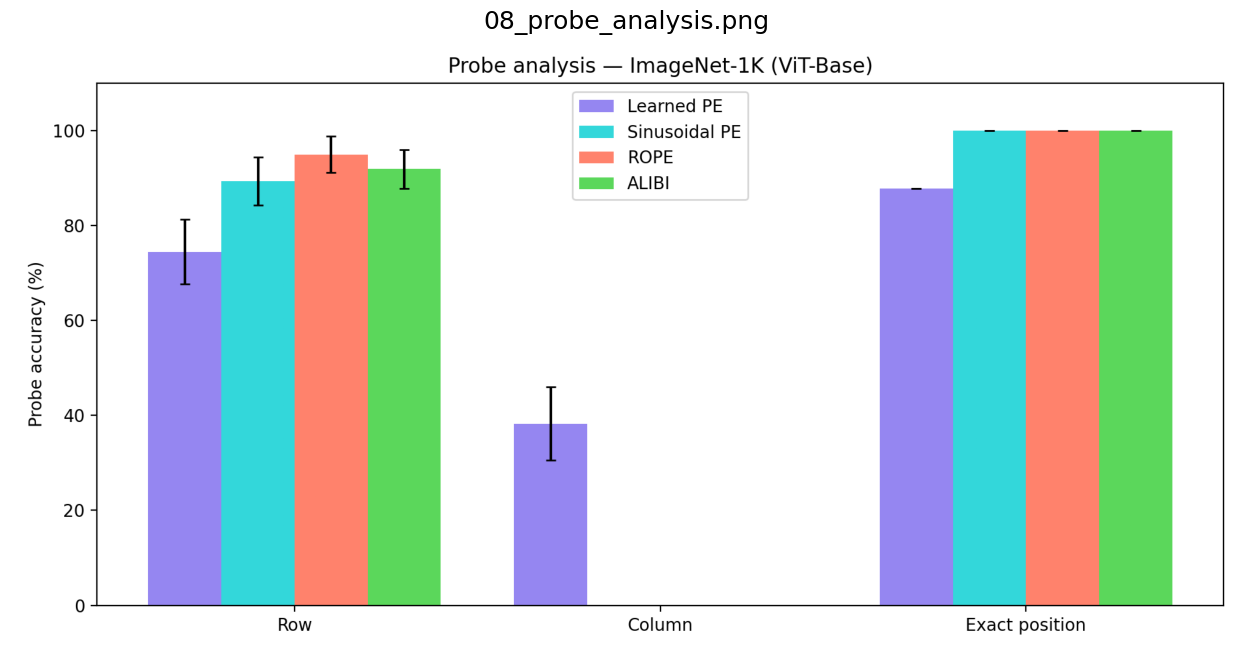

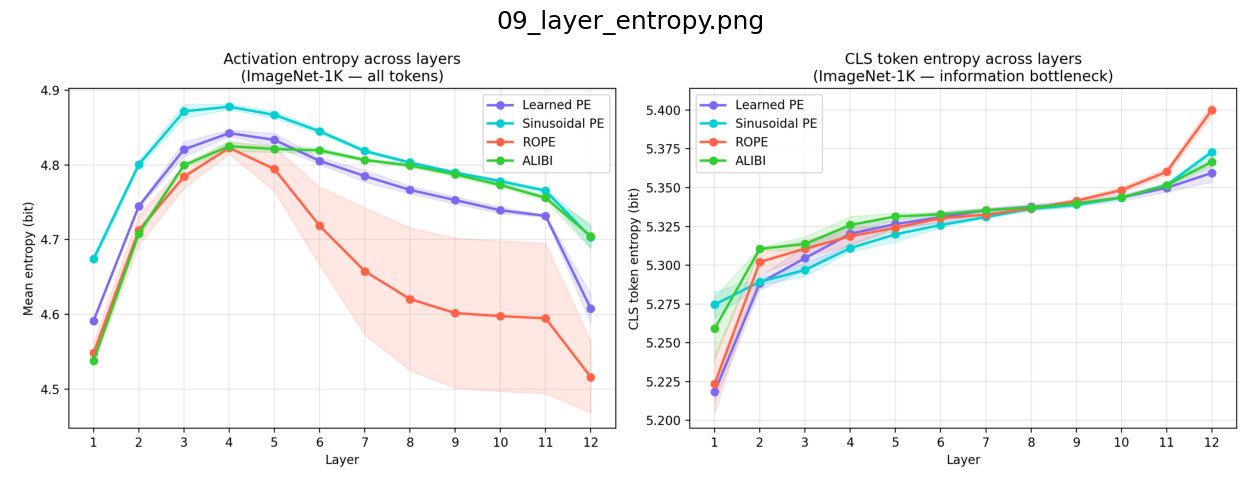

In [20]:
# Display generated figures
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

fig_dir = os.path.join(RESULTS_DIR, 'figures')
if os.path.exists(fig_dir) and os.listdir(fig_dir):
    for fig_name in sorted(os.listdir(fig_dir)):
        if fig_name.endswith('.png'):
            img = mpimg.imread(os.path.join(fig_dir, fig_name))
            plt.figure(figsize=(16, 8))
            plt.imshow(img); plt.axis('off'); plt.title(fig_name)
            plt.show()
else:
    print('No figures found — check for errors above')


In [30]:
import sys
import json
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Dodajemo /content u putanju kako bi Python video tvoju skriptu
sys.path.insert(0, '/content')

# Uvozimo tvoje originalne funkcije i klase iz skripte
from full_scale_experiment import (
    VisionTransformer, extract_positional_embedding,
    plot_cosine_similarity, plot_pca_tsne,
    plot_dimension_entropy, plot_variance_per_dim,
    plot_noise_ablation
)

# 2. Definisanje putanja
RESULTS_DIR = "/content/drive/My Drive/pe_experiment/results"
JSON_PATH = "/content/analysis_data.json"
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
pe_types = ['learned', 'sinusoidal', 'rope', 'alibi']
config = {'img_size': 224, 'patch_size': 16, 'num_classes': 100, 'embed_dim': 768, 'depth': 12, 'num_heads': 12, 'mlp_ratio': 4.0, 'dropout': 0.1}

print("============================================================")
print("🚀 INSTANT GENERISANJE SVIH GRAFIKONA - FINALNI BYPASS")
print("============================================================")

# ============================================================
# KORAK 1: Učitavanje JSON-a i direktno pakovanje u formate skripte
# ============================================================
print("\n[1/3] Učitavam numeričke podatke iz JSON-a...")
with open(JSON_PATH, "r") as f:
    analysis_data = json.load(f)

all_ablation = {}
all_probe_clean = {} # Pravimo čist rečnik za probe analizu koji ne može da pukne

for pe_type in pe_types:
    temp_noise_levels = None
    temp_accuracies = []
    temp_no_pe = []

    probe_rows = []
    probe_cols = []
    probe_pos = []

    if pe_type in analysis_data:
        for seed, metrics in analysis_data[pe_type].items():

            # --- Formatiranje za Noise Ablation ---
            if 'noise_ablation' in metrics:
                ab_data = metrics['noise_ablation']
                if temp_noise_levels is None:
                    temp_noise_levels = ab_data['noise_levels']
                temp_accuracies.append(ab_data['accuracies'])
                if 'accuracy_no_pe' in ab_data:
                    temp_no_pe.append(ab_data['accuracy_no_pe'])

            # --- Formatiranje za Probe Analysis ---
            if 'probe' in metrics:
                p_data = metrics['probe']
                probe_rows.append(p_data['row']['mean'])
                probe_cols.append(p_data['column']['mean'])
                probe_pos.append(p_data['position']['mean'])

    if temp_noise_levels is not None:
        all_ablation[pe_type] = {
            'noise_levels': temp_noise_levels,
            'accuracies': np.array(temp_accuracies),
            'acc_no_pe': temp_no_pe
        }

    if probe_rows:
        all_probe_clean[pe_type] = {
            'row_mean': np.mean(probe_rows),
            'row_std': np.std(probe_rows),
            'col_mean': np.mean(probe_cols),
            'col_std': np.std(probe_cols),
            'pos_mean': np.mean(probe_pos),
            'pos_std': np.std(probe_pos)
        }

# ============================================================
# KORAK 2: Brzo očitavanje težina modela (za strukturne grafike)
# ============================================================
print("\n[2/3] Učitavam .pth modele za ekstrakciju PE matrica...")
all_pe_matrices = {}

for pe_type in pe_types:
    model_path = os.path.join(RESULTS_DIR, f'{pe_type}_seed42', 'best_model.pth')
    if os.path.exists(model_path):
        model = VisionTransformer(pe_type=pe_type, **config).to(device)

        state_dict = torch.load(model_path, map_location=device)
        fixed_state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
        model.load_state_dict(fixed_state_dict)

        pe_matrix = extract_positional_embedding(model, pe_type)
        if pe_matrix is not None:
            all_pe_matrices[pe_type] = pe_matrix
            print(f"  -> Izvučena strukturna matrica za: {pe_type}")

# ============================================================
# KORAK 3: Pozivanje Matplotlib funkcija (koristi tvoj novi stil)
# ============================================================
print("\n[3/3] Pokrećem crtanje figura na bazi tvog novog stila...")

# Globalna primena tvojih fontova direktno pre crtanja
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'figure.titlesize': 18,
    'legend.fontsize': 12,
    'figure.dpi': 150,
    'savefig.bbox': 'tight'
})

if all_pe_matrices:
    print("  🎨 Generišem Figure 2: Cosine Similarity Heatmaps...")
    plot_cosine_similarity(all_pe_matrices, FIG_DIR)

    print("  🎨 Generišem Figure 3: PCA and t-SNE...")
    plot_pca_tsne(all_pe_matrices, FIG_DIR)

    print("  🎨 Generišem Figure 4: Dimension Entropy...")
    plot_dimension_entropy(all_pe_matrices, FIG_DIR)

    print("  🎨 Generišem Figure 5: Variance per Dimension...")
    plot_variance_per_dim(all_pe_matrices, FIG_DIR)

if all_ablation:
    print("  🎨 Generišem Figure 7: Noise Ablation...")
    plot_noise_ablation(all_ablation, FIG_DIR)

# LOKALNA I SIGURNA RELELEMENTACIJA ZA FIGURE 8 (PROBE) KOJA NE MOŽE DA PUKNE
if all_probe_clean:
    print("  🎨 Generišem Figure 8: Probe Analysis (Bypass Plot)...")
    COLOR_MAP = {'learned': '#7B68EE', 'sinusoidal': '#00CED1', 'rope': '#FF6347', 'alibi': '#32CD32'}

    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(all_probe_clean))
    width = 0.25

    for i, pe_type in enumerate(all_probe_clean):
        c = COLOR_MAP.get(pe_type, '#888')
        d = all_probe_clean[pe_type]

        lbl = pe_type.upper() if pe_type in ('rope', 'alibi') else f"{pe_type.capitalize()} PE"

        if i == 0:
            ax.bar(x[i] - width, d['row_mean'], width, yerr=d['row_std'], color=c, alpha=0.9, label='Row Accuracy')
            ax.bar(x[i], d['col_mean'], width, yerr=d['col_std'], color=c, alpha=0.6, label='Column Accuracy')
            ax.bar(x[i] + width, d['pos_mean'], width, yerr=d['pos_std'], color=c, alpha=0.3, label='Exact Position')
        else:
            ax.bar(x[i] - width, d['row_mean'], width, yerr=d['row_std'], color=c, alpha=0.9)
            ax.bar(x[i], d['col_mean'], width, yerr=d['col_std'], color=c, alpha=0.6)
            ax.bar(x[i] + width, d['pos_mean'], width, yerr=d['pos_std'], color=c, alpha=0.3)

    ax.set_ylabel('Probing Accuracy (%)')
    ax.set_title('Linear Probing Analysis across PE Architectures')
    ax.set_xticks(x)
    ax.set_xticklabels([k.upper() if k in ('rope', 'alibi') else k.capitalize() for k in all_probe_clean.keys()])
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    plt.savefig(os.path.join(FIG_DIR, '08_probe_analysis.png'))
    plt.close()

print("\n" + "="*60)
print(f"✅ SVE JE KONAČNO USPEŠNO ZAVRŠENO! Grafikoni te čekaju na Drive-u:\n{FIG_DIR}")
print("="*60)

🚀 INSTANT GENERISANJE SVIH GRAFIKONA - FINALNI BYPASS

[1/3] Učitavam numeričke podatke iz JSON-a...

[2/3] Učitavam .pth modele za ekstrakciju PE matrica...
  -> Izvučena strukturna matrica za: learned
  -> Izvučena strukturna matrica za: sinusoidal
  -> Izvučena strukturna matrica za: rope
  -> Izvučena strukturna matrica za: alibi

[3/3] Pokrećem crtanje figura na bazi tvog novog stila...
  🎨 Generišem Figure 2: Cosine Similarity Heatmaps...
  🎨 Generišem Figure 3: PCA and t-SNE...
  🎨 Generišem Figure 4: Dimension Entropy...
  🎨 Generišem Figure 5: Variance per Dimension...
  🎨 Generišem Figure 7: Noise Ablation...
  🎨 Generišem Figure 8: Probe Analysis (Bypass Plot)...

✅ SVE JE KONAČNO USPEŠNO ZAVRŠENO! Grafikoni te čekaju na Drive-u:
/content/drive/My Drive/pe_experiment/results/figures
